# Modeling

Two pieces: a transparent risk **score** for eligibility, and a **capacity** estimate for sizing. We have no default labels, so this is unsupervised - the score is a weighted blend of downside/consistency features, and the capacity comes from thinking about the payment distribution rather than a single predicted number.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data import load_payments
from src.preprocessing import preprocess
from src.features import build_features
from src.models import (HeuristicRiskModel, simulate_totals,
                        capacity_percentile, stress_capacity)
from src.utils import WEEK_COLUMNS, LOAN_WEEKS, DEDUCTION_RATE

df = preprocess(load_payments())
feats = build_features(df)
model = HeuristicRiskModel().fit(feats)
scores = model.score(feats)
scores.describe()

count    1275.000000
mean        0.517508
std         0.194649
min         0.046307
25%         0.385983
50%         0.529894
75%         0.653837
max         0.967546
Name: risk_score, dtype: float64

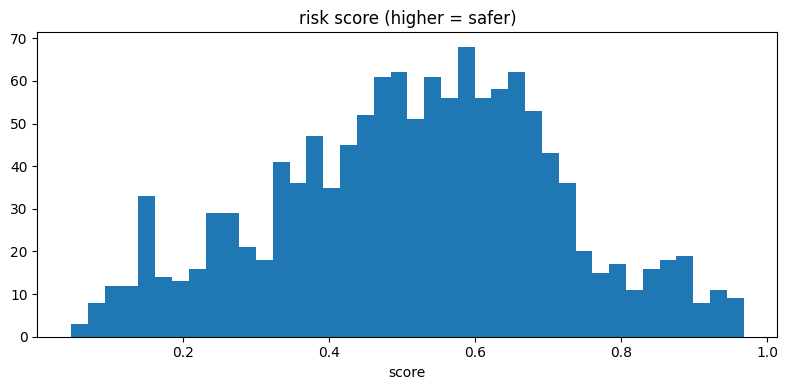

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=40)
ax.set_title('risk score (higher = safer)'); ax.set_xlabel('score'); plt.tight_layout()

The weights are readable - you can see exactly why a farmer scored where they did:

In [4]:
model.weights

{'active_week_pct': 1.5,
 'min_roll13_mean': 1.5,
 'p10_payment': 1.0,
 'recent_vs_history': 0.5,
 'norm_entropy': 0.75,
 'coef_variation': -1.5,
 'longest_zero_streak': -1.0,
 'downside_deviation': -0.75}

## Sizing: why not just use the average?
Take one farmer. If we simulate the next 13 weeks by resampling their own history, the **total** clusters near 13x the mean because summing 13 weeks averages out the bad ones. That distribution is fine for expected value, but it barely dips low enough to protect us if the loan lands in a bad stretch.

iid p10  : 151,611
block p10: 109,896
stress   : 0


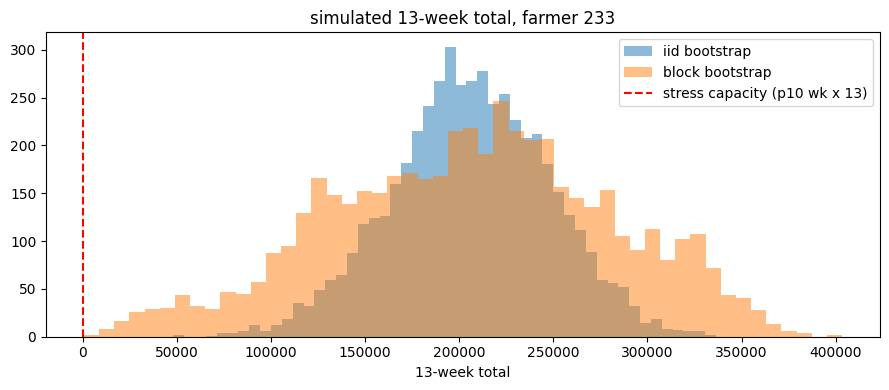

In [5]:
fid = scores.sort_values().index[len(scores)//2]  # a middling farmer
hist = df.loc[fid, WEEK_COLUMNS].to_numpy(float)
rng = np.random.default_rng(0)
iid = simulate_totals(hist, method='bootstrap', rng=rng)
block = simulate_totals(hist, method='block', rng=rng)
stress = stress_capacity(hist)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(iid, bins=50, alpha=0.5, label='iid bootstrap')
ax.hist(block, bins=50, alpha=0.5, label='block bootstrap')
ax.axvline(stress, color='red', ls='--', label='stress capacity (p10 wk x 13)')
ax.set_title(f'simulated 13-week total, farmer {fid}'); ax.set_xlabel('13-week total')
ax.legend(); plt.tight_layout()
print('iid p10  :', f'{capacity_percentile(iid):,.0f}')
print('block p10:', f'{capacity_percentile(block):,.0f}')
print('stress   :', f'{stress:,.0f}')

The stress capacity (red line) - assume every one of the 13 weeks pays like the farmer's 10th-percentile week - sits well below both simulated distributions. That's the number we size loans against. It's pessimistic on purpose, because the backtest in notebook 04 shows the yearly trough is deeper than anything the bootstrap produces. The simulation stays useful as a picture of the *expected* outcome; the stress number is what protects the book.

## Saving the model
The scorer only needs the population feature ranges it normalizes against, so it serializes to a small JSON.

In [6]:
import tempfile, os
p = os.path.join(tempfile.gettempdir(), 'risk_model.json')
model.save(p)
print(open(p).read()[:300], '...')

{
  "weights": {
    "active_week_pct": 1.5,
    "min_roll13_mean": 1.5,
    "p10_payment": 1.0,
    "recent_vs_history": 0.5,
    "norm_entropy": 0.75,
    "coef_variation": -1.5,
    "longest_zero_streak": -1.0,
    "downside_deviation": -0.75
  },
  "ranges": {
    "active_week_pct": [
      0.38 ...
